# Notebook 5-de_LDS: Results Analysis and Visualization (de_LDS with AUPRC)

This notebook analyzes de_LDS classification experiments with AUPRC metric:
- 6 de_LDS experiments (6 models × 1 feature)
- Metrics: Accuracy, F1, Precision, Recall, **AUPRC**
- PERCLOS Threshold: 0.4

It generates:
- Comprehensive comparison tables with AUPRC
- Performance visualizations including AUPRC
- Best model identification
- Summary report

## 1. Import Dependencies

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("Dependencies loaded")

Dependencies loaded


## 2. Load de_LDS Results

In [2]:
# Paths
BASE_DIR = Path('/home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG')
RESULTS_DIR = BASE_DIR / 'results' / 'baselines'

# MODIFIED: Load de_LDS classification results
classification_path = RESULTS_DIR / 'classification_de_LDS_results.json'
with open(classification_path, 'r') as f:
    classification_results = json.load(f)

print(f"Loaded de_LDS classification results")
print(f"Feature types: {list(classification_results.keys())}")
print(f"Models evaluated: {len(classification_results.get('de_LDS', {}))}")

Loaded de_LDS classification results
Feature types: ['de_LDS']
Models evaluated: 6


## 3. Create Summary DataFrame

In [3]:
# Model parameter counts (from Notebook 2)
MODEL_PARAMS = {
    'mlp': 21410,
    'cnn_single': 23298,
    'cnn_multi': 101378,
    'eegnet': 730,
    'decnn': 118018,
    'transformer': 70562
}

# Classification DataFrame - MODIFIED: Added AUPRC
clf_data = []

for feature_key, models_dict in classification_results.items():
    for model_name, metrics in models_dict.items():
        if 'error' not in metrics:  # Skip failed experiments
            clf_data.append({
                'Task': 'Classification',
                'Feature': feature_key,
                'Model': model_name,
                'Params': MODEL_PARAMS.get(model_name, 0),
                'Accuracy': metrics['acc'],
                'F1': metrics['f1'],
                'Precision': metrics['precision'],
                'Recall': metrics['recall'],
                'AUPRC': metrics['auprc']  # NEW
            })

df_clf = pd.DataFrame(clf_data)

print("DataFrame created")
print(f"Classification: {df_clf.shape}")
print(f"Columns: {list(df_clf.columns)}")

DataFrame created
Classification: (6, 9)
Columns: ['Task', 'Feature', 'Model', 'Params', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUPRC']


## 4. Classification Results Analysis

In [4]:
print("="*100)
print("CLASSIFICATION RESULTS (de_LDS with AUPRC, threshold=0.4)")
print("="*100)
print(df_clf.to_string(index=False))
print("="*100)

# Statistics - MODIFIED: Added AUPRC
print("\nClassification Statistics:")
print(df_clf[['Accuracy', 'F1', 'Precision', 'Recall', 'AUPRC']].describe())

CLASSIFICATION RESULTS (de_LDS with AUPRC, threshold=0.4)
          Task Feature       Model  Params  Accuracy       F1  Precision   Recall    AUPRC
Classification  de_LDS         mlp   21410  0.715254 0.669869   0.580621 0.791538 0.790737
Classification  de_LDS  cnn_single   23298  0.745386 0.708621   0.608438 0.848297 0.806902
Classification  de_LDS   cnn_multi  101378  0.686319 0.688672   0.542553 0.942505 0.705948
Classification  de_LDS      eegnet     730  0.751036 0.694123   0.629195 0.773994 0.683781
Classification  de_LDS       decnn  118018  0.623729 0.651065   0.492080 0.961816 0.741281
Classification  de_LDS transformer   70562  0.746139 0.706446   0.611153 0.836945 0.783150

Classification Statistics:
       Accuracy        F1  Precision    Recall     AUPRC
count  6.000000  6.000000   6.000000  6.000000  6.000000
mean   0.711311  0.686466   0.577340  0.859183  0.751966
std    0.049524  0.022281   0.051555  0.077359  0.049748
min    0.623729  0.651065   0.492080  0.773994  0

## 5. Best Model for de_LDS

In [5]:
print("="*100)
print("BEST MODEL FOR de_LDS (Highest F1)")
print("="*100)

feature_key = 'de_LDS'
feature_clf = df_clf[df_clf['Feature'] == feature_key]

if len(feature_clf) > 0:
    best_idx = feature_clf['F1'].idxmax()
    best = feature_clf.loc[best_idx]
    
    print(f"\nFeature: {feature_key}")
    print(f"  Model:     {best['Model']}")
    print(f"  Accuracy:  {best['Accuracy']:.4f}")
    print(f"  F1:        {best['F1']:.4f}")
    print(f"  Precision: {best['Precision']:.4f}")
    print(f"  Recall:    {best['Recall']:.4f}")
    print(f"  AUPRC:     {best['AUPRC']:.4f}")  # NEW
    print(f"  Params:    {best['Params']:,}")

print("\n" + "="*100)

BEST MODEL FOR de_LDS (Highest F1)

Feature: de_LDS
  Model:     cnn_single
  Accuracy:  0.7454
  F1:        0.7086
  Precision: 0.6084
  Recall:    0.8483
  AUPRC:     0.8069
  Params:    23,298



## 6. Visualization: F1 vs AUPRC Comparison

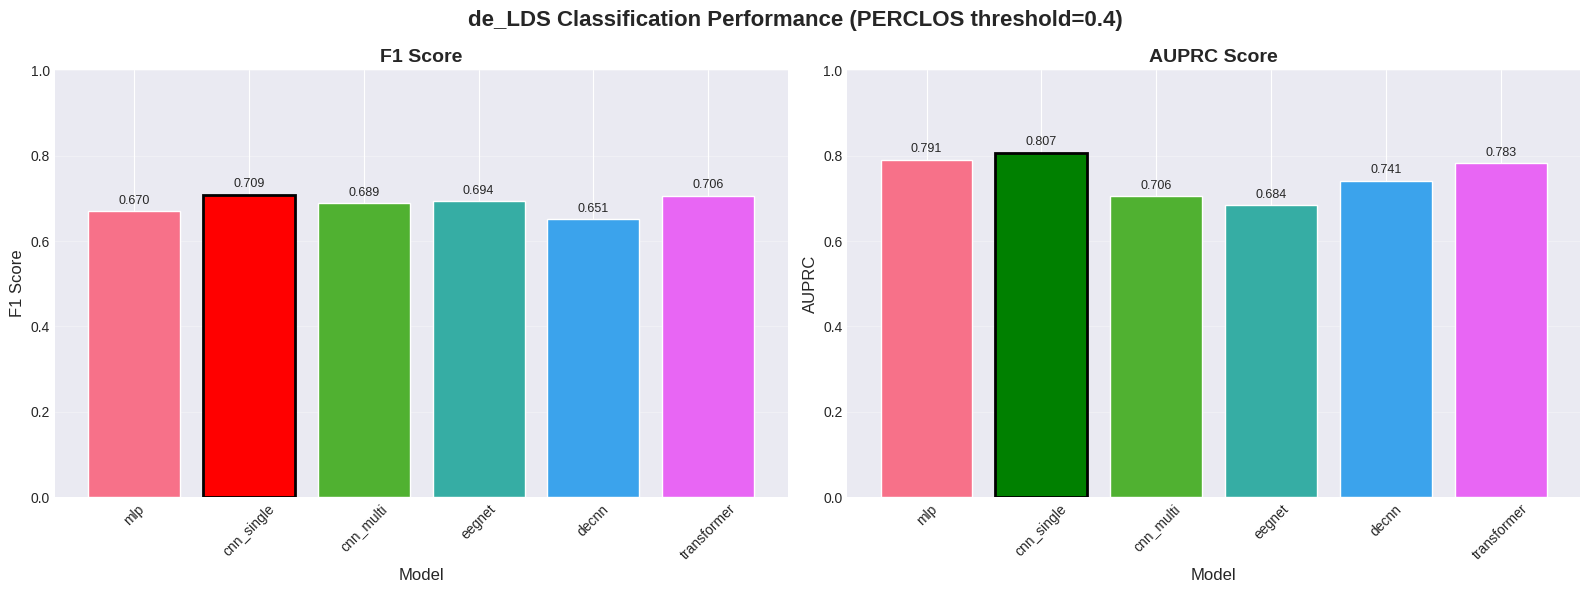

F1 and AUPRC comparison plot saved


In [6]:
# NEW: Dual bar chart comparing F1 and AUPRC
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('de_LDS Classification Performance (PERCLOS threshold=0.4)', fontsize=16, fontweight='bold')

feature_data = df_clf[df_clf['Feature'] == 'de_LDS']
models = feature_data['Model'].values

# Plot 1: F1 Score
ax1 = axes[0]
f1_scores = feature_data['F1'].values
bars = ax1.bar(models, f1_scores, color=sns.color_palette('husl', len(models)))

# Highlight best F1
best_idx = np.argmax(f1_scores)
bars[best_idx].set_color('red')
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2)

ax1.set_title('F1 Score', fontsize=14, fontweight='bold')
ax1.set_xlabel('Model', fontsize=12)
ax1.set_ylabel('F1 Score', fontsize=12)
ax1.set_ylim([0, 1])
ax1.grid(axis='y', alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: AUPRC Score
ax2 = axes[1]
auprc_scores = feature_data['AUPRC'].values
bars = ax2.bar(models, auprc_scores, color=sns.color_palette('husl', len(models)))

# Highlight best AUPRC
best_idx = np.argmax(auprc_scores)
bars[best_idx].set_color('green')
bars[best_idx].set_edgecolor('black')
bars[best_idx].set_linewidth(2)

ax2.set_title('AUPRC Score', fontsize=14, fontweight='bold')
ax2.set_xlabel('Model', fontsize=12)
ax2.set_ylabel('AUPRC', fontsize=12)
ax2.set_ylim([0, 1])
ax2.grid(axis='y', alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'de_LDS_f1_auprc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("F1 and AUPRC comparison plot saved")

## 7. Visualization: All 5 Metrics Grouped Bar Chart

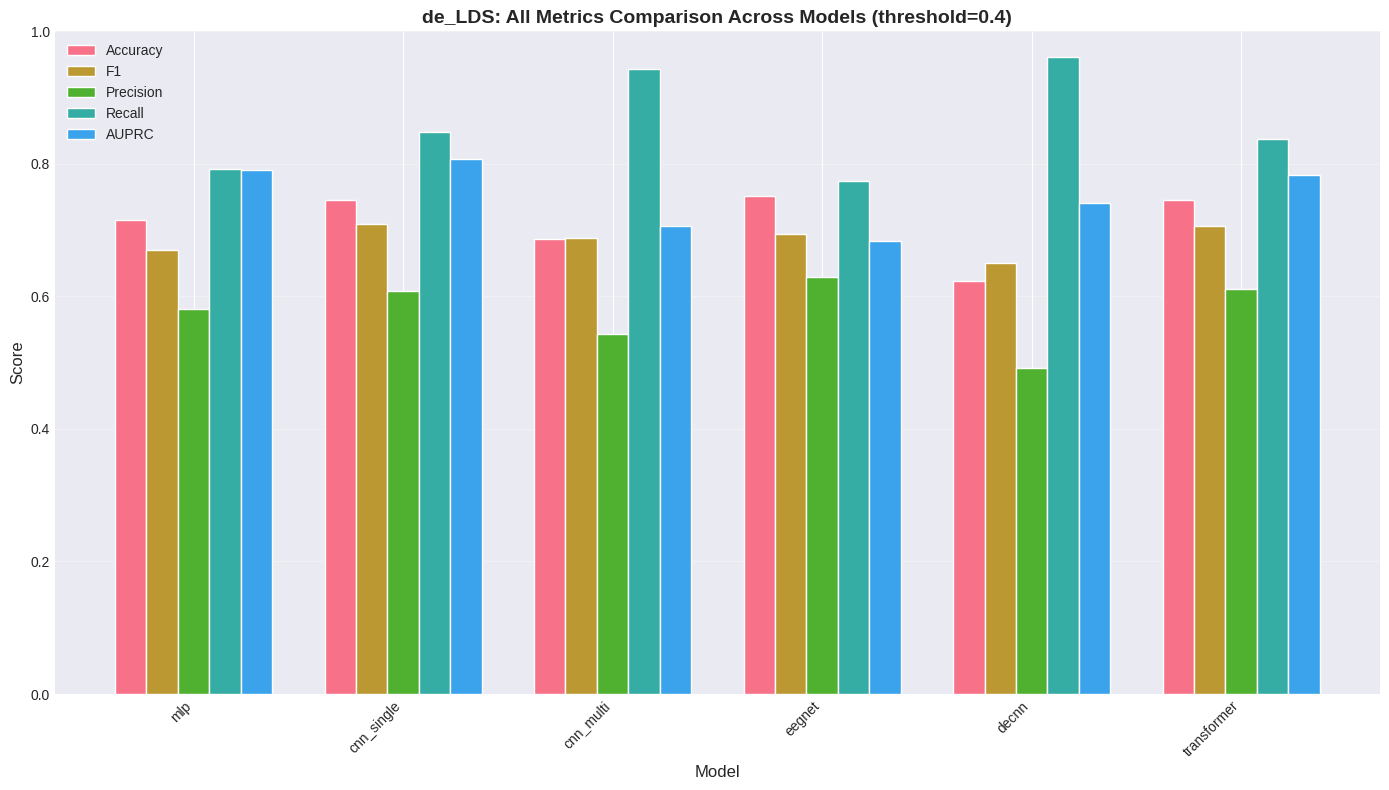

All metrics comparison plot saved


In [7]:
# NEW: All 5 metrics in grouped bar chart
fig, ax = plt.subplots(figsize=(14, 8))

feature_data = df_clf[df_clf['Feature'] == 'de_LDS']
models = feature_data['Model'].values
metrics_to_plot = ['Accuracy', 'F1', 'Precision', 'Recall', 'AUPRC']

x = np.arange(len(models))
width = 0.15

for i, metric in enumerate(metrics_to_plot):
    values = feature_data[metric].values
    offset = (i - 2) * width  # Center the bars
    ax.bar(x + offset, values, width, label=metric)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('de_LDS: All Metrics Comparison Across Models (threshold=0.4)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'de_LDS_all_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print("All metrics comparison plot saved")

## 8. Visualization: Metrics Heatmap

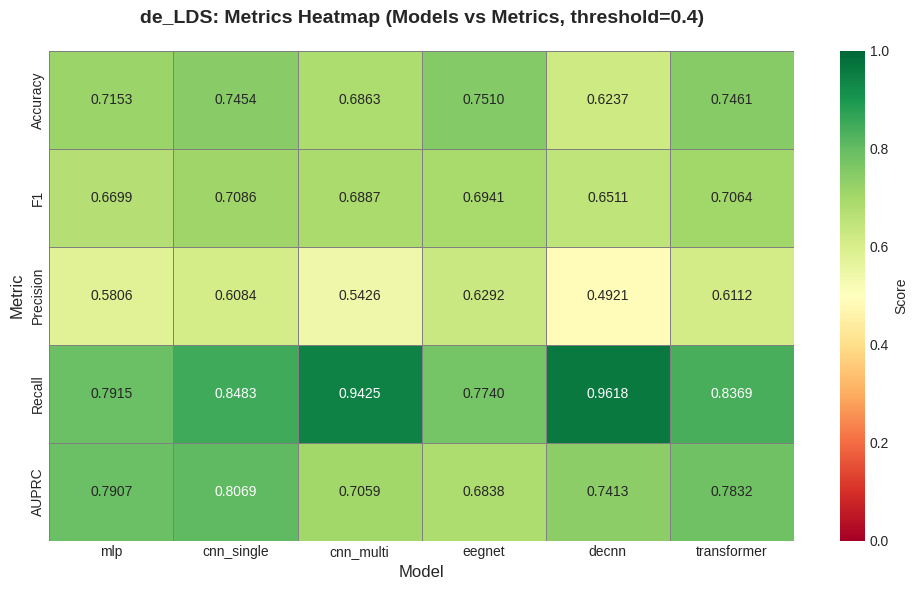

Metrics heatmap saved


In [8]:
# NEW: Heatmap of all 5 metrics
metrics_data = feature_data[['Model', 'Accuracy', 'F1', 'Precision', 'Recall', 'AUPRC']].copy()
metrics_data = metrics_data.set_index('Model')

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_data.T, annot=True, fmt='.4f', cmap='RdYlGn', 
            vmin=0, vmax=1, cbar_kws={'label': 'Score'}, 
            linewidths=0.5, linecolor='gray')
plt.title('de_LDS: Metrics Heatmap (Models vs Metrics, threshold=0.4)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Metric', fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'de_LDS_metrics_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Metrics heatmap saved")

## 9. Visualization: Model Complexity vs Performance

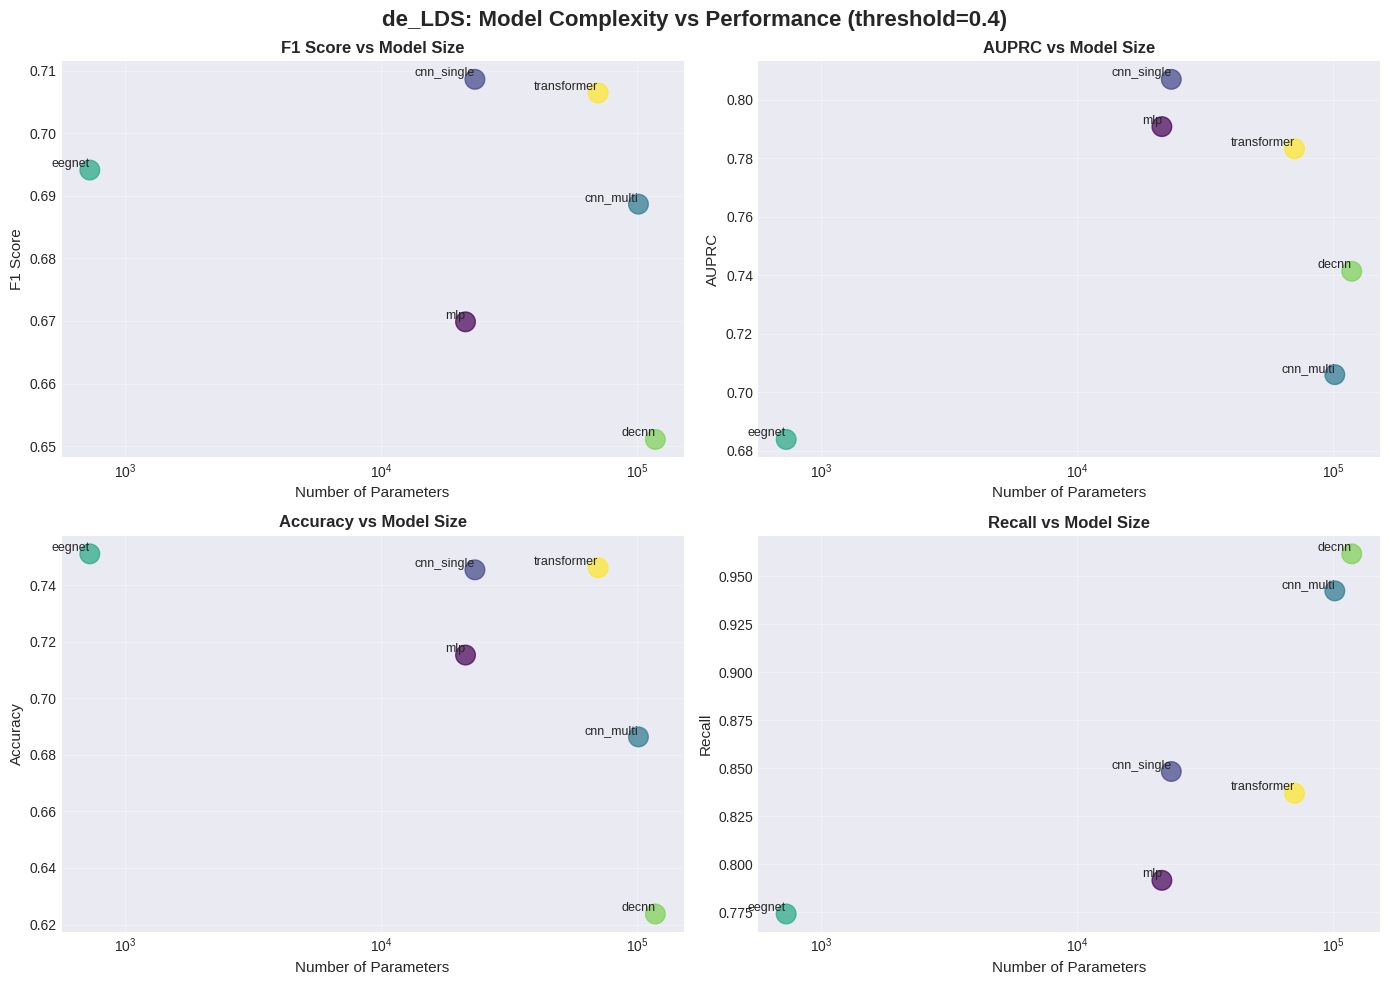

Complexity vs performance plots saved


In [9]:
# MODIFIED: 2x2 grid with F1, AUPRC, Accuracy, Recall
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('de_LDS: Model Complexity vs Performance (threshold=0.4)', fontsize=16, fontweight='bold')

feature_data = df_clf[df_clf['Feature'] == 'de_LDS']
metrics_to_plot = [('F1', 'F1 Score'), ('AUPRC', 'AUPRC'), 
                   ('Accuracy', 'Accuracy'), ('Recall', 'Recall')]

for idx, (metric, label) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    
    ax.scatter(feature_data['Params'], feature_data[metric], 
               s=200, alpha=0.7, c=range(len(feature_data)), cmap='viridis')
    
    # Annotate points with model names
    for _, row in feature_data.iterrows():
        ax.annotate(row['Model'], (row['Params'], row[metric]),
                   fontsize=9, ha='right', va='bottom')
    
    ax.set_xlabel('Number of Parameters', fontsize=11)
    ax.set_ylabel(label, fontsize=11)
    ax.set_title(f'{label} vs Model Size', fontsize=12, fontweight='bold')
    ax.set_xscale('log')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'de_LDS_complexity_vs_performance.png', dpi=300, bbox_inches='tight')
plt.show()

print("Complexity vs performance plots saved")

## 10. Export Summary Tables

In [10]:
# Save detailed results
df_clf.to_csv(RESULTS_DIR / 'de_LDS_detailed.csv', index=False)

# Create summary table with formatted values
summary_data = []
for _, row in feature_data.iterrows():
    summary_data.append({
        'Model': row['Model'],
        'Parameters': f"{row['Params']:,}",
        'Accuracy': f"{row['Accuracy']*100:.2f}%",
        'F1': f"{row['F1']:.4f}",
        'Precision': f"{row['Precision']:.4f}",
        'Recall': f"{row['Recall']:.4f}",
        'AUPRC': f"{row['AUPRC']:.4f}"  # NEW
    })

df_summary = pd.DataFrame(summary_data)
df_summary.to_csv(RESULTS_DIR / 'de_LDS_summary.csv', index=False)

print("All result tables exported:")
print(f"  - {RESULTS_DIR / 'de_LDS_detailed.csv'}")
print(f"  - {RESULTS_DIR / 'de_LDS_summary.csv'}")

print("\nAll visualizations saved:")
print(f"  - {RESULTS_DIR / 'de_LDS_f1_auprc_comparison.png'}")
print(f"  - {RESULTS_DIR / 'de_LDS_all_metrics.png'}")
print(f"  - {RESULTS_DIR / 'de_LDS_metrics_heatmap.png'}")
print(f"  - {RESULTS_DIR / 'de_LDS_complexity_vs_performance.png'}")

All result tables exported:
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/de_LDS_detailed.csv
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/de_LDS_summary.csv

All visualizations saved:
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/de_LDS_f1_auprc_comparison.png
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/de_LDS_all_metrics.png
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/de_LDS_metrics_heatmap.png
  - /home/vortex/CSE 465/SFM1/Project/CSE465_EEG-20251204T160245Z-3-001/CSE465_EEG/results/baselines/de_LDS_complexity_vs_performance.png


## 11. Final Summary Statistics

In [11]:
print("="*100)
print("de_LDS EXPERIMENT SUMMARY (PERCLOS threshold=0.4)")
print("="*100)

print(f"\nTotal Models Tested: {len(feature_data)}")
for model in feature_data['Model'].unique():
    print(f"  - {model}")

print(f"\nPerformance Range:")
print(f"  - F1 Score:  [{feature_data['F1'].min():.4f}, {feature_data['F1'].max():.4f}]")
print(f"  - AUPRC:     [{feature_data['AUPRC'].min():.4f}, {feature_data['AUPRC'].max():.4f}]")  # NEW
print(f"  - Accuracy:  [{feature_data['Accuracy'].min():.4f}, {feature_data['Accuracy'].max():.4f}]")
print(f"  - Precision: [{feature_data['Precision'].min():.4f}, {feature_data['Precision'].max():.4f}]")
print(f"  - Recall:    [{feature_data['Recall'].min():.4f}, {feature_data['Recall'].max():.4f}]")

print(f"\nBest Models:")
for metric in ['F1', 'AUPRC', 'Accuracy']:
    best_idx = feature_data[metric].idxmax()
    best_model = feature_data.loc[best_idx, 'Model']
    best_score = feature_data.loc[best_idx, metric]
    print(f"  - Highest {metric}: {best_model} ({best_score:.4f})")

print(f"\nModel Size Range:")
print(f"  - Parameters: [{feature_data['Params'].min():,}, {feature_data['Params'].max():,}]")

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)
print("\nNote: Results use PERCLOS threshold=0.4, which is stricter than the original 0.35.")
print("These results cannot be directly compared to models trained with threshold=0.35.")
print("="*100)

de_LDS EXPERIMENT SUMMARY (PERCLOS threshold=0.4)

Total Models Tested: 6
  - mlp
  - cnn_single
  - cnn_multi
  - eegnet
  - decnn
  - transformer

Performance Range:
  - F1 Score:  [0.6511, 0.7086]
  - AUPRC:     [0.6838, 0.8069]
  - Accuracy:  [0.6237, 0.7510]
  - Precision: [0.4921, 0.6292]
  - Recall:    [0.7740, 0.9618]

Best Models:
  - Highest F1: cnn_single (0.7086)
  - Highest AUPRC: cnn_single (0.8069)
  - Highest Accuracy: eegnet (0.7510)

Model Size Range:
  - Parameters: [730, 118,018]

ANALYSIS COMPLETE

Note: Results use PERCLOS threshold=0.4, which is stricter than the original 0.35.
These results cannot be directly compared to models trained with threshold=0.35.


## Summary

This notebook analyzed 6 de_LDS classification experiments with AUPRC metric and generated:

**Tables:**
- `de_LDS_detailed.csv` - All de_LDS results with 5 metrics
- `de_LDS_summary.csv` - Formatted summary table

**Visualizations:**
- `de_LDS_f1_auprc_comparison.png` - F1 vs AUPRC dual bar chart
- `de_LDS_all_metrics.png` - All 5 metrics grouped bar chart
- `de_LDS_metrics_heatmap.png` - Metrics heatmap (models × metrics)
- `de_LDS_complexity_vs_performance.png` - Model size vs performance (F1, AUPRC, Accuracy, Recall)

All results are saved to `results/baselines/`

**Key Findings:**
- PERCLOS threshold of 0.4 (vs original 0.35) creates stricter alertness criteria
- AUPRC provides additional insight into precision-recall trade-off
- Results complement the standard classification metrics